In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep"
)

In [2]:
df = pd.read_csv("DCP_data/ai4i2020.csv")

In [3]:
df.head() #checking he first 5 rows

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
df.tail() #checking the last 5 rows

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0,0,0,0,0,0


In [5]:
#checking the shape of dataset
print("--- Shape ---")
print(f"{df.shape[0]} rows, {df.shape[1]} columns")

--- Shape ---
10000 rows, 14 columns


In [6]:
df.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [8]:
#checking for duplicate
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [9]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


### Key Findings

### Dataset Overview
- The AI4I dataset contains 10,000 observations and 14 variables.
- The variables consist of equipment identifiers, operating parameters, maintenance information, and failure labels.
### Data Quality
- No missing values were found.
- No duplicate records were found.
- The dataset is complete and suitable for further analysis.
### Data Types
- Most variables are numerical.
- Product ID and Type are categorical.
- Failure variables are binary (0 = No Failure, 1 = Failure).
### Initial Observation
The dataset appears clean and requires little preprocessing.
Feature engineering and exploratory data analysis can proceed without major data quality concerns.

### EDA

In [11]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [12]:
(df["Machine failure"].value_counts(normalize=True)*100).round(2)

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

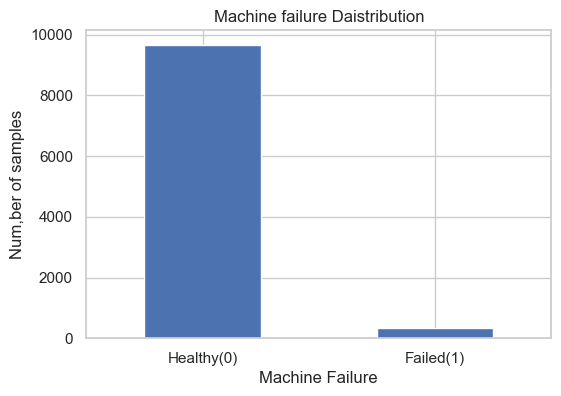

In [13]:
failure_counts = df["Machine failure"].value_counts()
plt.figure(figsize = (6,4))
failure_counts.plot(kind="bar")
plt.title("Machine failure Daistribution")
plt.xlabel("Machine Failure")
plt.ylabel("Num,ber of samples")
plt.xticks([0,1], ["Healthy(0)", "Failed(1)"], rotation=0)
plt.show()

### Interpretation
The dataset contains significantly more healthy machines than failed machines. Approximately 96.6% of the observations represent normal operating conditions, while only about 3.4% represent machine failures. This indicates that the dataset is highly imbalanced, which is expected in industrial environments because machines typically operate normally for long periods before a failure occurs. Consequently, special consideration must be given during model development to address class imbalance and ensure that failure cases are accurately detected.

### 4.2 Numerical variable analysis
#How are operatin conditions distributed during machine oerations?
We will analyze only these five variables:

- Air temperature [K]
- Process temperature [K]
- Rotational speed [rpm]
- Torque [Nm]
- Tool wear [min]

These are the variables that describe the machine's operating condition.

In [14]:
numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0


The summary statistics indicate that the dataset contains 10,000 observations for each operating parameter, confirming that there are no missing values in the selected numerical features. Air and process temperatures exhibit relatively low variability, suggesting that the machines operate within controlled thermal conditions. In contrast, rotational speed, torque, and tool wear show greater variability, reflecting changes in machine loading and operating conditions. Tool wear ranges from 0 to 253 minutes, indicating that the dataset captures equipment at different stages of its operational life, from new to heavily worn. These observations suggest that the dataset is suitable for investigating how changes in operating conditions influence machine failures.

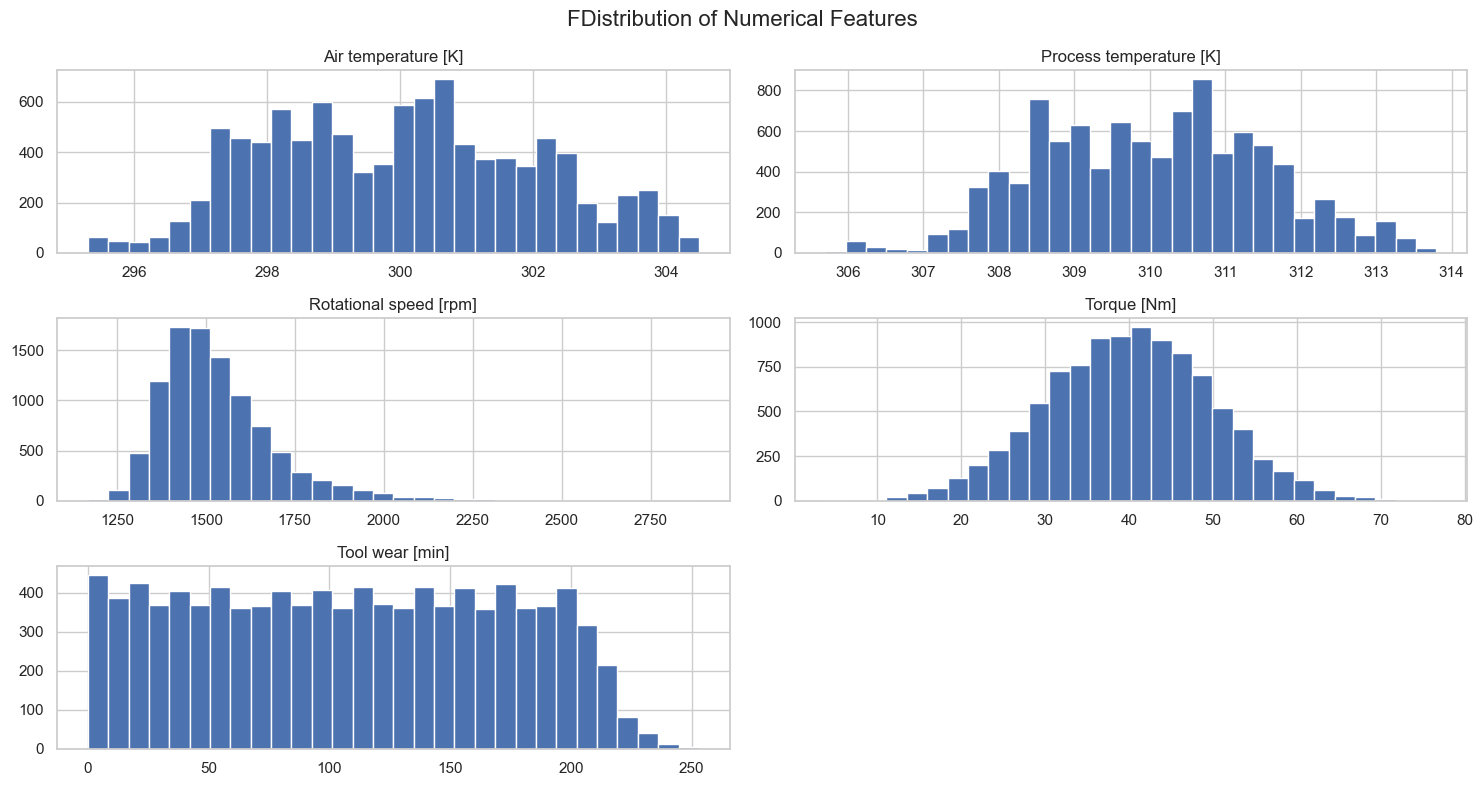

In [15]:
df[numerical_features].hist(figsize=(15,8), bins=30)
plt.suptitle("FDistribution of Numerical Features", fontsize = 16)
plt.tight_layout()

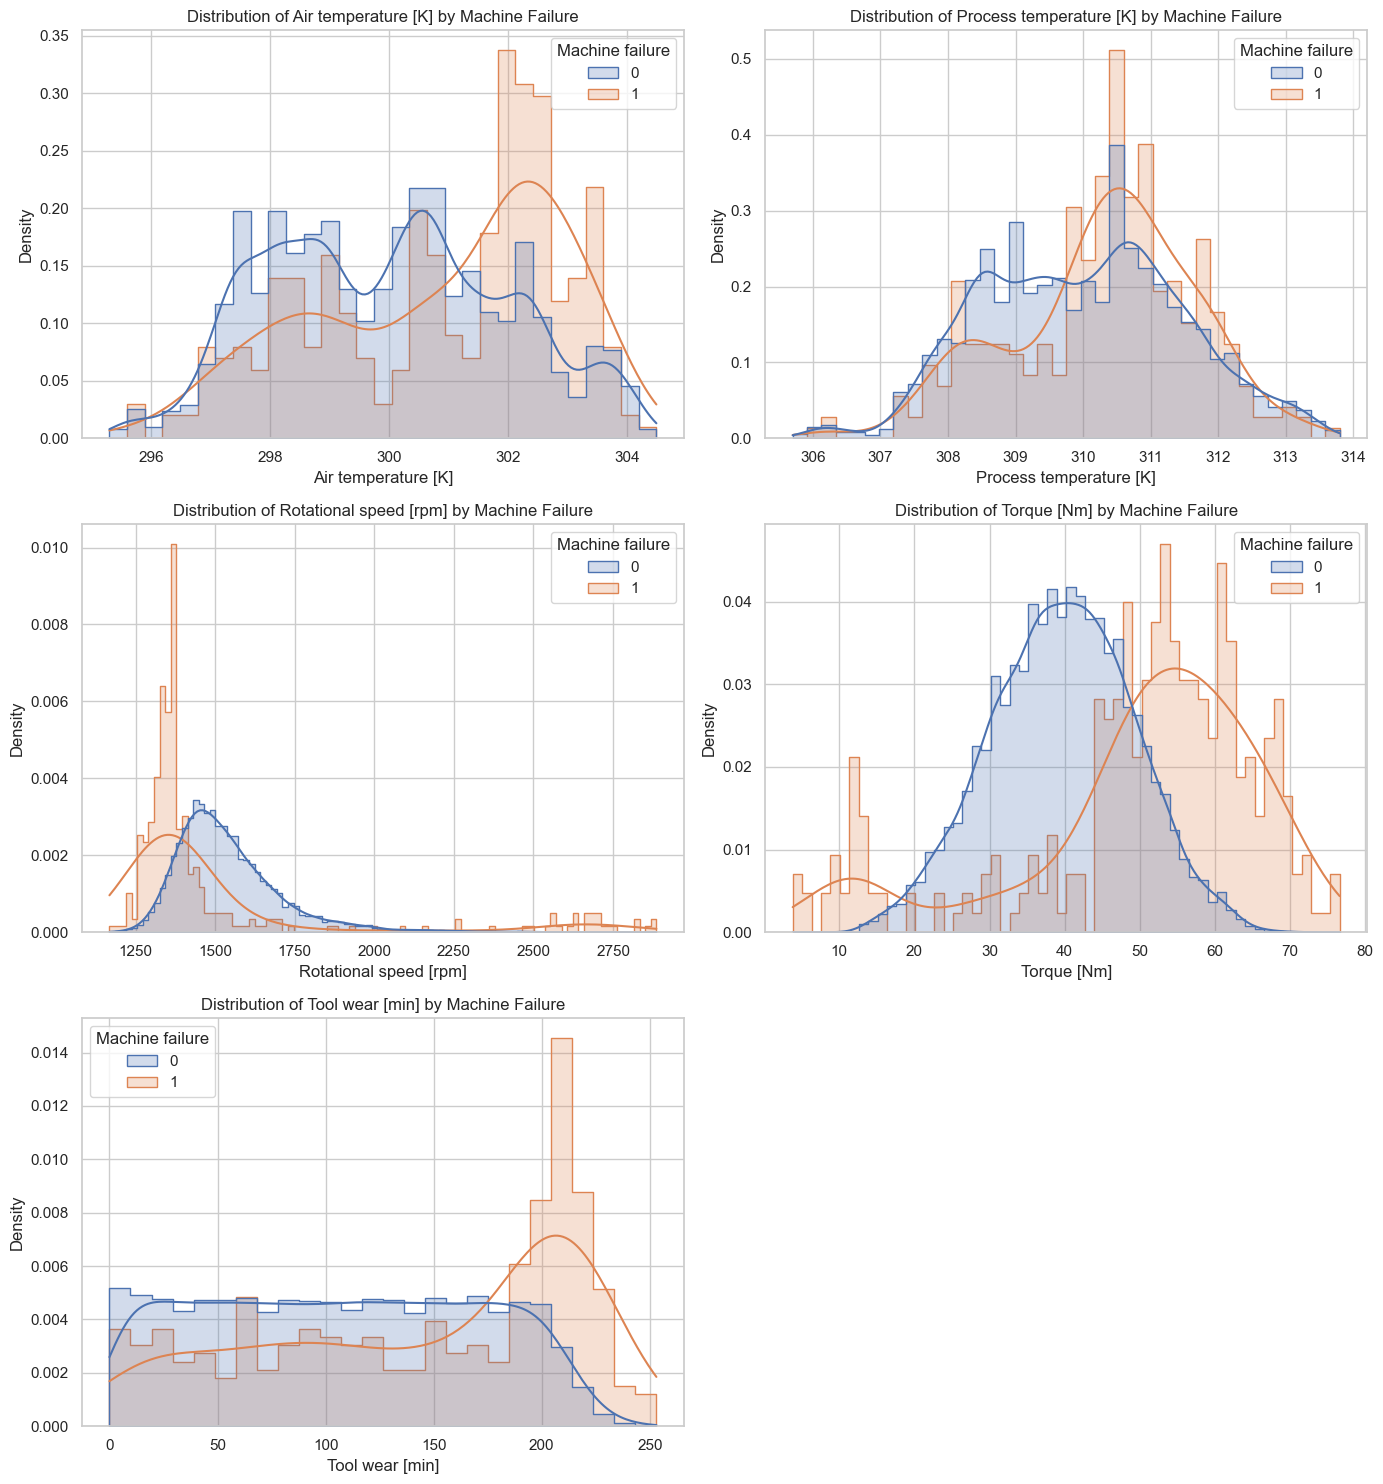

In [16]:
# Select the numerical variables describing operating conditions
num_vars = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

# Set up the matplotlib figure grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 15))
axes = axes.flatten() # Flatten the 2D array to easily loop through it

# Plot a distribution for each variable, colored by Machine Failure
for i, var in enumerate(num_vars):
    sns.histplot(
        data=df,
        x=var,
        hue="Machine failure",  # Capitalized 'Failure' to fix the ValueError
        kde=True,
        element="step",
        stat="density",
        common_norm=False,
        palette="deep",
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {var} by Machine Failure")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Density")

# Remove the empty 6th subplot space
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

The histogram analysis shows that the operating variables exhibit different distribution patterns. Torque follows an approximately symmetric bell-shaped distribution, indicating that the machine operates around a typical loading condition for most observations. Rotational speed is positively skewed, suggesting that the equipment operates predominantly within a normal speed range, with fewer observations at higher speeds. Both air temperature and process temperature are concentrated within relatively narrow operating ranges, reflecting controlled thermal conditions during machine operation. Tool wear is distributed over a wide range, representing machines at different stages of their service life, although the abrupt decline after approximately 200 minutes suggests that the dataset may have been generated under controlled experimental conditions rather than continuous industrial operation. Overall, the variables exhibit realistic operational ranges suitable for predictive maintenance analysis, while some distribution characteristics indicate that the dataset is semi-synthetic and should be interpreted accordingly.

## 4.3 Outlier Detection
Are there abnormal operating conditions that could indicate excessive stress or impending failure?

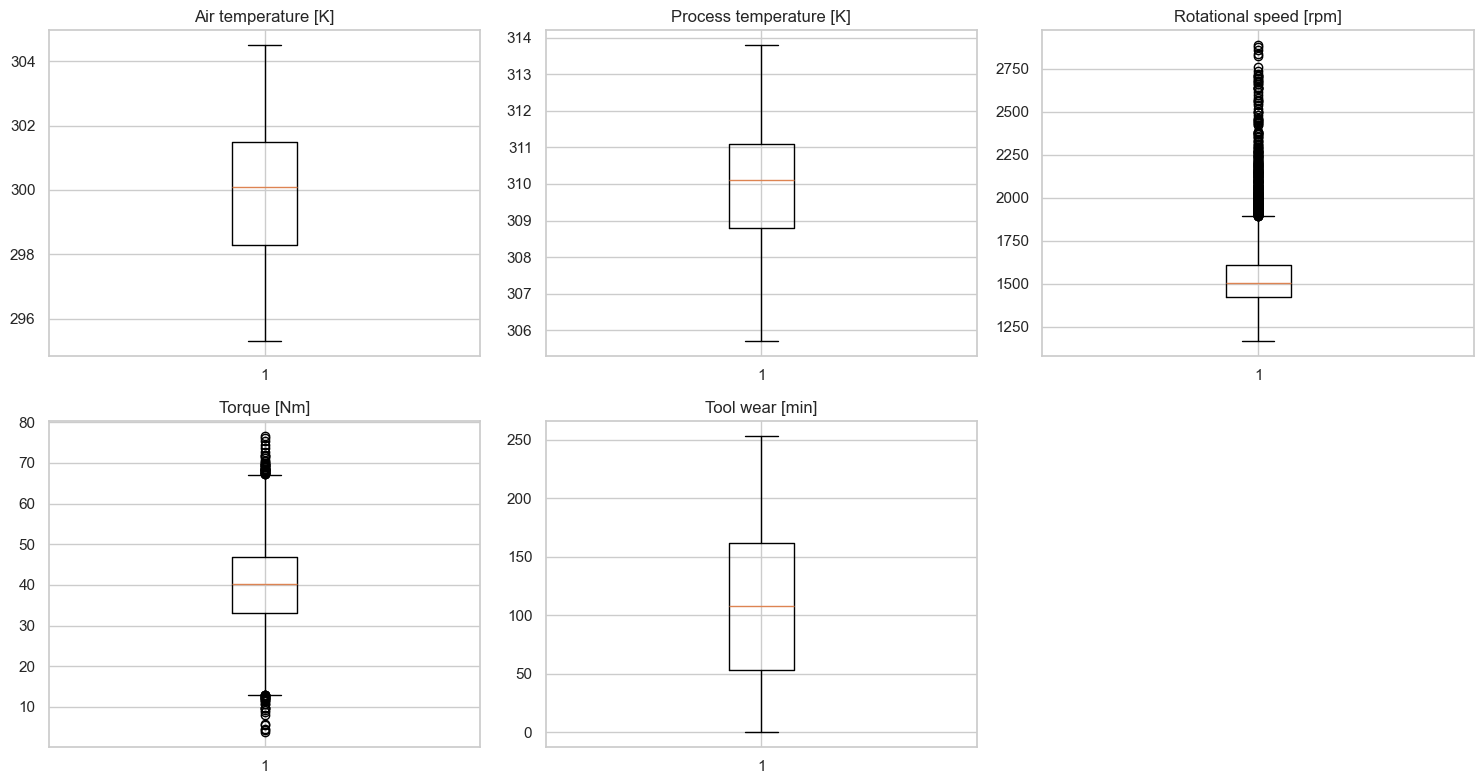

In [17]:
plt.figure(figsize = (15, 8))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(df[feature], vert=True)
    plt.title(feature)
plt.tight_layout()

Outlier Analysis

The boxplots indicate that rotational speed and torque contain observations beyond the upper whiskers, while air temperature, process temperature, and tool wear exhibit little or no statistical outliers. The largest concentration of outliers occurs in rotational speed, followed by torque. These observations do not appear to be measurement errors, as they form continuous operating ranges rather than isolated abnormal values. From a predictive maintenance perspective, such extreme operating conditions may represent periods of increased mechanical stress that precede equipment failure. Consequently, these observations will be retained for subsequent analysis because they are likely to contain valuable information for identifying early warning signs rather than representing erroneous data.

## Section 4.4 – Correlation Analysis
Which operating parameters are most strongly related to each other?

This helps us:

- understand machine behaviour,
- identify redundant variables,
- justify our engineered features (e.g., Temperature Difference),
- and prepare for model development.

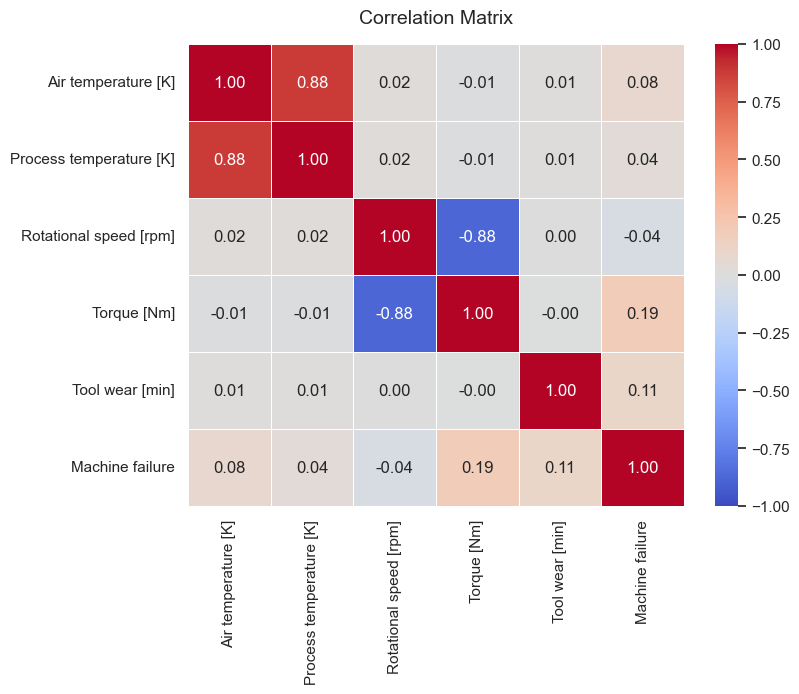

In [18]:
# Compute the correlation matrix
correlation = df[
    [
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]",
        "Machine failure"
    ]
].corr()

# Set up the figure size
plt.figure(figsize=(8, 6))

# Plot the heatmap (Seaborn handles labels and positioning automatically)
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)

# Set the title
plt.title("Correlation Matrix", fontsize=14, pad=15)

plt.show()

The correlation analysis indicates that none of the individual operating variables exhibits a strong linear relationship with machine failure. Torque shows the highest positive correlation (0.19), while rotational speed exhibits a weak negative correlation (-0.04). Air and process temperatures demonstrate only weak positive relationships with failure. These findings suggest that equipment failure is not driven by a single operating parameter but rather by the combined interaction of multiple mechanical and thermal conditions. Consequently, engineering-based feature construction is justified to better capture these interactions. Features such as Temperature Difference, Power Index, Wear Intensity, and Thermal Stress Index will therefore be developed and evaluated during the feature engineering stage.

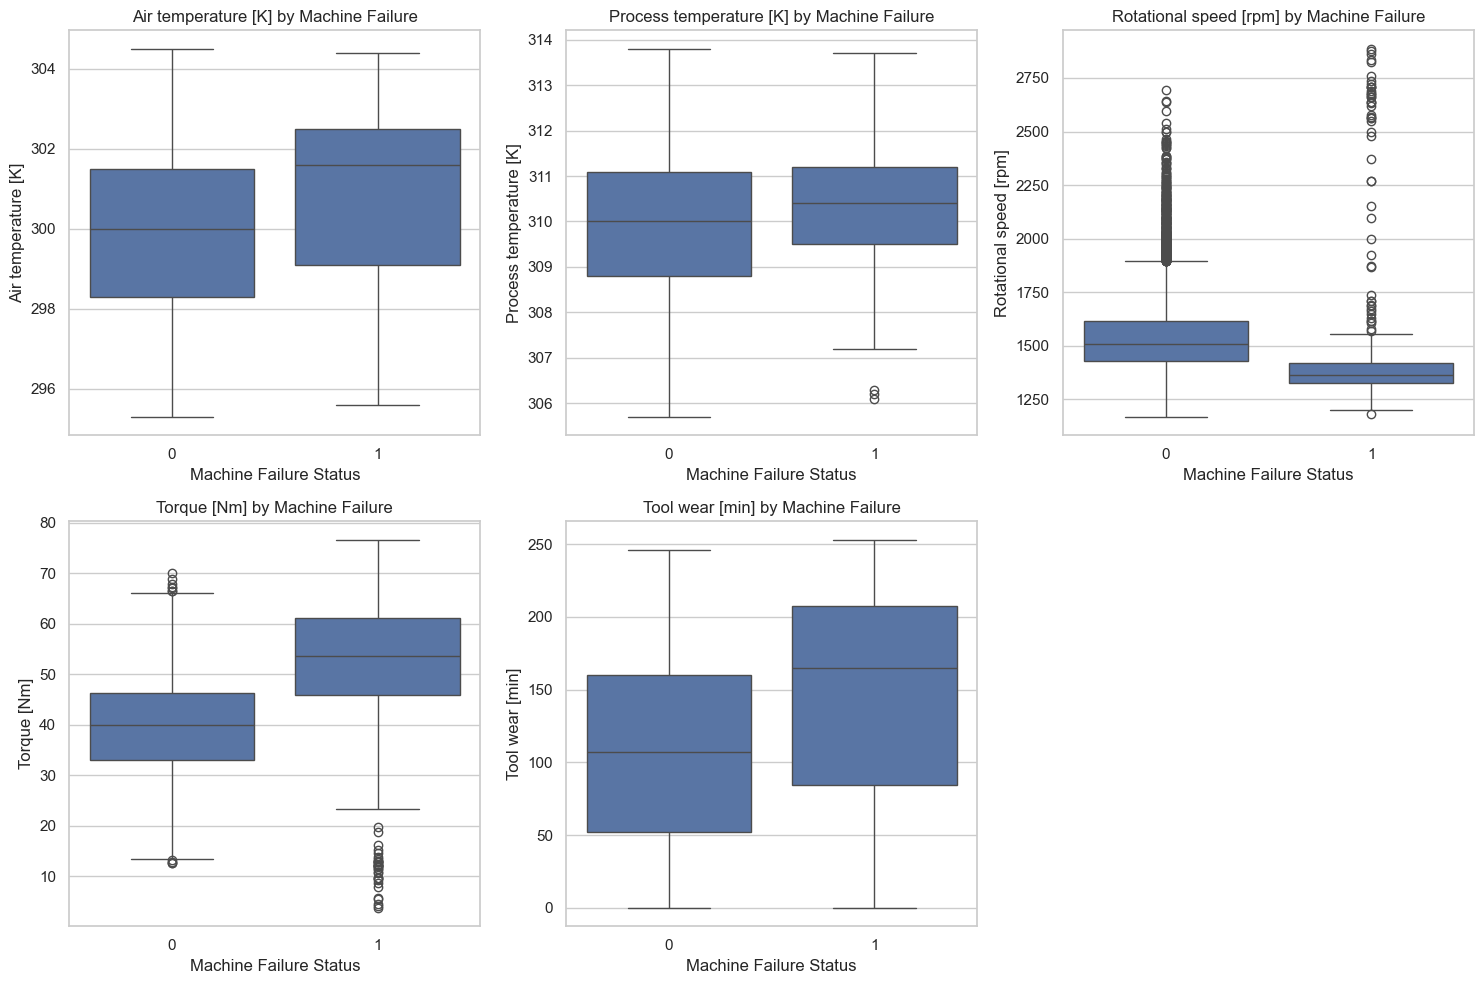

In [19]:
features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

plt.figure(figsize=(15, 10))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    
    # Use seaborn boxplot grouped by the 'Machine failure' target variable
    sns.boxplot(
        data=df,
        x="Machine failure",
        y=feature
    )
    
    plt.title(f"{feature} by Machine Failure")
    plt.xlabel("Machine Failure Status")
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

## Final Interpretation
### Failure-Based Analysis
#### Air Temperature

Failed machines generally operate at slightly higher air temperatures than healthy machines, as indicated by the upward shift in the median and interquartile range. Although the difference is moderate, it suggests that elevated ambient operating conditions may contribute to increased failure risk. On its own, air temperature is unlikely to be a strong predictor, but it may become more informative when combined with other operating variables.

#### Process Temperature

Failed machines exhibit higher process temperatures than healthy machines. The upward shift in the distribution suggests that increased operating temperature is associated with machine failure. Since process temperature is strongly correlated with air temperature, a derived feature such as Temperature Difference may better represent internally generated heat and provide a stronger indicator of equipment condition.

#### Rotational Speed

Machines that experience failure generally operate at lower rotational speeds, although a number of failures also occur at unusually high speeds. This indicates that failure can occur under different operating regimes, suggesting that rotational speed alone is insufficient to explain machine breakdown. Instead, its interaction with torque should be considered during feature engineering.

#### Torque

Torque exhibits the most pronounced separation between healthy and failed machines. Failed machines generally operate under higher torque conditions, indicating increased mechanical loading. This observation supports the hypothesis that excessive mechanical stress is an important contributor to equipment failure and justifies the development of load-related engineered features.

#### Tool Wear

Failed machines generally exhibit higher tool wear than healthy machines, indicating that accumulated wear increases the likelihood of failure. Although failures may still occur at lower wear levels, the overall distribution suggests that equipment degradation is an important indicator of machine health and should be incorporated into the predictive maintenance framework.

### Feature Engineering
Can we create new variables that better represent machine health than the raw sensor measurements?
#### Feature 1 – Temperature Difference
Engineering Reason

The EDA showed:

Air Temperature and Process Temperature are highly correlated (≈0.88).
Failed machines generally operate at higher process temperatures.

However, raw temperatures don't tell us how much heat the machine itself is generating.

The difference between the two temperatures is a better indicator of internal thermal loading.

Formula
Temperature Difference=Process Temperature−Air Temperature

In [20]:
df["Temperature Difference"] = (
    df["Process temperature [K]"] -
    df["Air temperature [K]"]
)


Temperature Difference=Process Temperature−Air Temperature

estimates the additional heat generated by the machine itself, removing the effect of ambient conditions.

This concept is widely used in condition monitoring, but the exact feature is designed by the engineer, not defined by an international standard.

In our project, we must justify it with our EDA, not because "everyone uses it."

The same applies to the other features—we'll justify each one using engineering principles and the data.

In [21]:
df["Temperature Difference"].describe()

count    10000.000000
mean        10.000630
std          1.001094
min          7.600000
25%          9.300000
50%          9.800000
75%         11.000000
max         12.100000
Name: Temperature Difference, dtype: float64

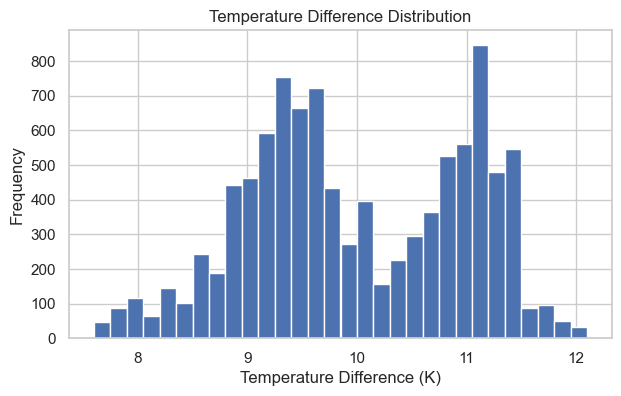

In [22]:
plt.figure(figsize=(7,4))

plt.hist(df["Temperature Difference"], bins=30)

plt.title("Temperature Difference Distribution")
plt.xlabel("Temperature Difference (K)")
plt.ylabel("Frequency")

plt.show()

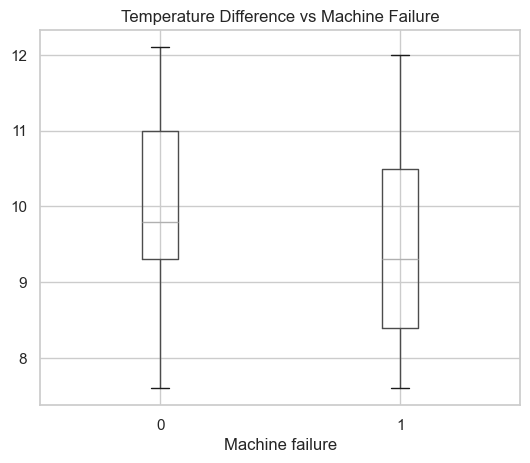

In [23]:
df.boxplot(
    column="Temperature Difference",
    by="Machine failure",
    figsize=(6,5)
)

plt.title("Temperature Difference vs Machine Failure")
plt.suptitle("")
plt.show()

Although Temperature Difference was hypothesized to represent internal thermal loading, exploratory analysis showed that it did not improve class separation. Therefore, the feature was excluded from the final predictive maintenance model

Power Index

This one has much stronger engineering justification.

Why?

A machine does work through rotation and torque, not either one alone.

From physics,

P=T×ω

where

P = Power
T = Torque
ω = Angular speed

Our dataset has RPM, not rad/s, so for ranking machine loading we can use a simplified engineering proxy:

In [24]:
df["Power Index"] = (
    df["Torque [Nm]"] *
    df["Rotational speed [rpm]"]
)

In [25]:
df["Power Index"].describe()

count    10000.000000
mean     59967.147040
std      10193.093881
min      10966.800000
25%      53105.400000
50%      59883.900000
75%      66873.750000
max      99980.400000
Name: Power Index, dtype: float64

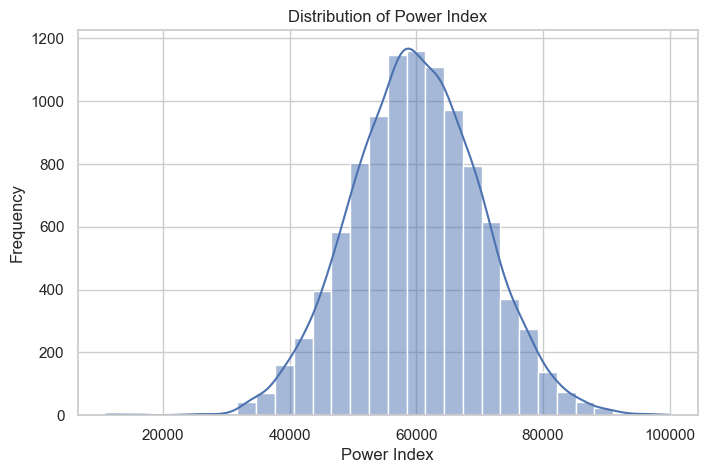

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Power Index",
    bins=30,
    kde=True
)

plt.title("Distribution of Power Index")
plt.xlabel("Power Index")
plt.ylabel("Frequency")

plt.show()

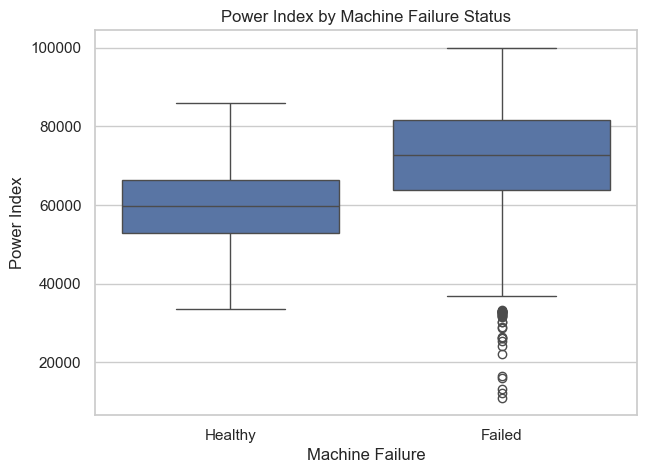

In [27]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Machine failure",
    y="Power Index"
)

plt.title("Power Index by Machine Failure Status")
plt.xlabel("Machine Failure")
plt.ylabel("Power Index")

plt.xticks([0,1], ["Healthy", "Failed"])

plt.show()

### Engineering Justification

Although Power Index does not separate healthy and failed machines more clearly than torque alone, it represents the combined effect of rotational speed and mechanical load, making it a more physically meaningful indicator of machine operating conditions. Since equipment failures often result from the interaction of multiple variables rather than a single measurement, Power Index is retained as an engineered feature for subsequent model evaluation.

## Wear Intensity

This one is even more intuitive.

Engineering Question

A machine with 150 minutes of tool wear operating at 20 Nm is very different from one with 150 minutes of tool wear operating at 60 Nm.

Both have the same wear.

But one is under much greater mechanical stress.

So we combine them.

Formula
Wear Intensity=Tool Wear×Torque

This represents the cumulative mechanical stress experienced by the machine.

In [28]:
df["Wear Intensity"] = (
    df["Tool wear [min]"] *
    df["Torque [Nm]"]
)

In [29]:
df["Wear Intensity"].describe()

count    10000.000000
mean      4314.664550
std       2826.567692
min          0.000000
25%       1963.650000
50%       4012.950000
75%       6279.000000
max      16497.000000
Name: Wear Intensity, dtype: float64

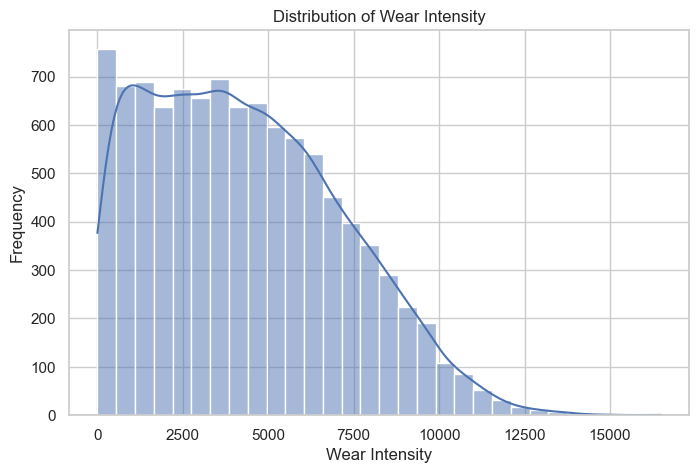

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Wear Intensity",
    bins=30,
    kde=True
)

plt.title("Distribution of Wear Intensity") # Fixed
plt.xlabel("Wear Intensity")                # Fixed
plt.ylabel("Frequency")

plt.show()

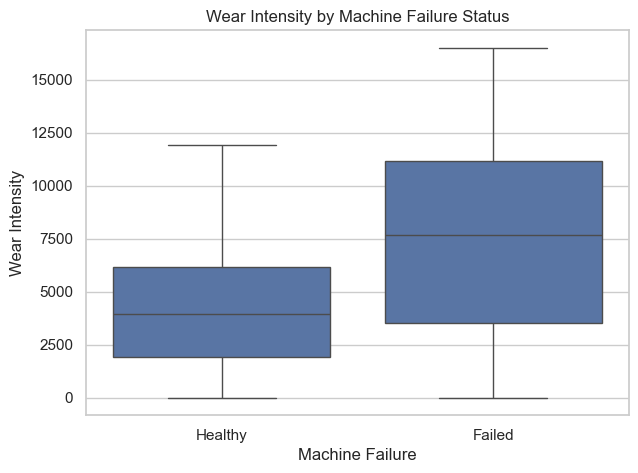

In [31]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Machine failure",
    y="Wear Intensity"
)

plt.title("Wear Intensity by Machine Failure Status")
plt.xlabel("Machine Failure")
plt.ylabel("Wear Intensity")

plt.xticks([0, 1], ["Healthy", "Failed"])

plt.show()

KEEP Wear Intensity
Engineering Justification

Wear Intensity combines cumulative equipment degradation (Tool Wear) with the mechanical load (Torque) experienced by the machine. Unlike Tool Wear alone, this engineered feature better differentiates healthy and failed machines by representing the combined effect of wear and operating stress. Since equipment deterioration is influenced by both service life and loading conditions, Wear Intensity provides a more realistic measure of machine health and will be retained for subsequent model evaluation.

In [32]:
df["Thermal Stress Index"] = (
    df["Process temperature [K]"] *
    df["Torque [Nm]"]
)

In [33]:
df["Thermal Stress Index"].describe()

count    10000.000000
mean     12395.956474
std       3090.377871
min       1170.400000
25%      10288.197500
50%      12432.135000
75%      14493.982500
max      23868.560000
Name: Thermal Stress Index, dtype: float64

## Healthy vs Failed

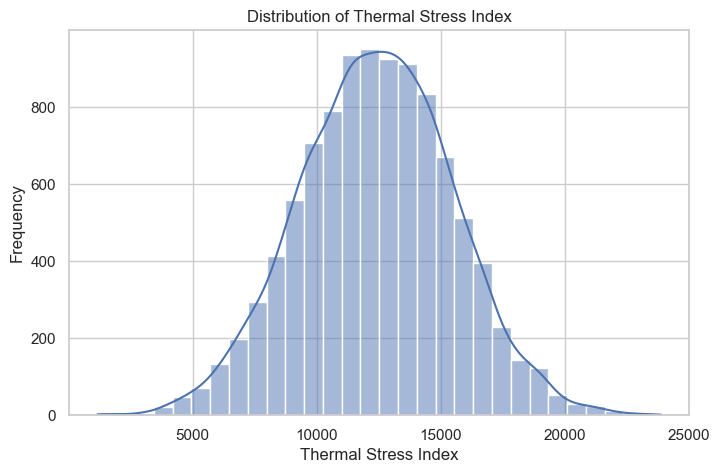

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Thermal Stress Index",
    bins=30,
    kde=True
)

plt.title("Distribution of Thermal Stress Index")
plt.xlabel("Thermal Stress Index")
plt.ylabel("Frequency")

plt.show()

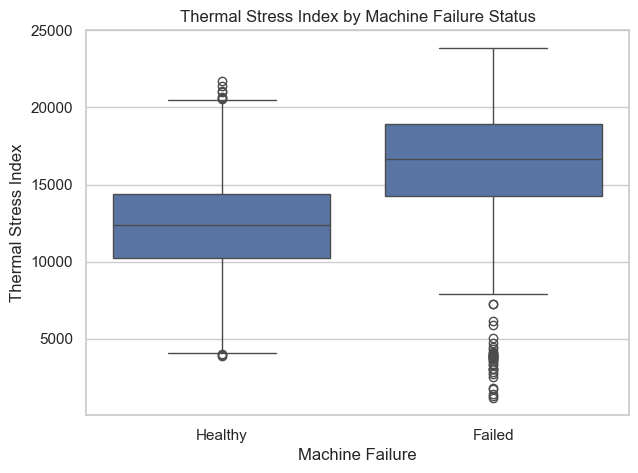

In [35]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Machine failure",
    y="Thermal Stress Index"
)

plt.title("Thermal Stress Index by Machine Failure Status")
plt.xlabel("Machine Failure")
plt.ylabel("Thermal Stress Index")

plt.xticks([0,1], ["Healthy","Failed"])

plt.show()

In [36]:
df[["Thermal Stress Index", "Machine failure"]].corr()

,Thermal Stress Index,Machine failure
Thermal Stress Index,1.000000,0.192224
Machine failure,0.192224,1.000000


### Engineering Justification

Thermal Stress Index combines process temperature and mechanical loading into a single indicator of equipment stress. Unlike process temperature alone, this engineered feature provides much clearer separation between healthy and failed machines, indicating that the interaction between thermal and mechanical conditions is more informative than either variable individually. Therefore, Thermal Stress Index will be retained for model development and Equipment Health Index (EHI) construction.

## Building the Model

In [37]:
import warnings
warnings.filterwarnings("ignore")

import json
import joblib
import datetime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    brier_score_loss
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import optuna
import shap

sns.set_theme(style="whitegrid")
optuna.logging.set_verbosity(optuna.logging.WARNING)
RANDOM_STATE = 42
N_SPLITS = 5
N_TRIALS = 25

COST_FN_OVER_FP = 1

In [38]:
# ---------------------------------
# Clean column names
# ---------------------------------

df.columns = (
    df.columns
      .str.replace("[", "", regex=False)
      .str.replace("]", "", regex=False)
      .str.replace("<", "", regex=False)
      .str.replace(">", "", regex=False)
      .str.replace("/", "_")
      .str.replace(" ", "_")
)

print("Columns after cleaning:\n")
print(df.columns.tolist())

Columns after cleaning:

['UDI', 'Product_ID', 'Type', 'Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Temperature_Difference', 'Power_Index', 'Wear_Intensity', 'Thermal_Stress_Index']


In [39]:
# ----------------------------------
# Feature Selection
# ----------------------------------

features = [

    "Air_temperature_K",

    "Process_temperature_K",

    "Rotational_speed_rpm",

    "Torque_Nm",

    "Tool_wear_min",

    "Power_Index",

    "Wear_Intensity",

    "Thermal_Stress_Index"

]

target = "Machine_failure"

X = df[features]

y = df[target]

print("Number of Features:", len(features))
print("Target:", target)

Number of Features: 8
Target: Machine_failure


In [40]:
# ----------------------------------
# Data Validation
# ----------------------------------

def validate_schema(data, features, target):

    required_columns = features + [target]

    missing_columns = [
        col for col in required_columns
        if col not in data.columns
    ]

    if missing_columns:
        raise ValueError(f"Missing columns: {missing_columns}")

    missing_values = data[required_columns].isnull().sum()

    if missing_values.any():
        raise ValueError(
            f"Missing values found:\n{missing_values[missing_values > 0]}"
        )

    non_numeric = data[features].select_dtypes(exclude=np.number)

    if non_numeric.shape[1] > 0:
        raise ValueError(
            f"Non-numeric feature(s): {list(non_numeric.columns)}"
        )

    print("Schema validation passed.")


validate_schema(df, features, target)

Schema validation passed.


In [41]:
# ----------------------------------
# Time-Ordered Train-Test Split
# ----------------------------------

df = df.sort_values("UDI").reset_index(drop=True)

split_index = int(len(df) * 0.80)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Training Samples :", len(train_df))
print("Testing Samples  :", len(test_df))

Training Samples : 8000
Testing Samples  : 2000


In [42]:
# ----------------------------------
# Handle Class Imbalance
# ----------------------------------

counter = Counter(y_train)

negative = counter[0]
positive = counter[1]

scale_pos_weight = negative / positive

print(counter)

print("\nScale Positive Weight")
print(scale_pos_weight)

print("\nTraining Distribution")
print(y_train.value_counts(normalize=True))

print("\nTesting Distribution")
print(y_test.value_counts(normalize=True))

Counter({0: 7700, 1: 300})

Scale Positive Weight
25.666666666666668

Training Distribution
Machine_failure
0    0.9625
1    0.0375
Name: proportion, dtype: float64

Testing Distribution
Machine_failure
0    0.9805
1    0.0195
Name: proportion, dtype: float64


In [43]:
# ----------------------------------
# Cross Validation Strategy
# ----------------------------------

cv = StratifiedKFold(

    n_splits=N_SPLITS,

    shuffle=True,

    random_state=RANDOM_STATE

)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [44]:
# ----------------------------------
# Optuna Objective Functions
# ----------------------------------

def objective_xgb(trial):

    params = {

        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "scale_pos_weight": scale_pos_weight,
        "eval_metric": "logloss",
        "random_state": RANDOM_STATE

    }

    scores = []

    for train_index, valid_index in cv.split(X_train, y_train):

        X_tr = X_train.iloc[train_index]
        X_val = X_train.iloc[valid_index]

        y_tr = y_train.iloc[train_index]
        y_val = y_train.iloc[valid_index]

        model = XGBClassifier(**params)

        model.fit(X_tr, y_tr)

        probability = model.predict_proba(X_val)[:, 1]

        scores.append(
            roc_auc_score(y_val, probability)
        )

    return np.mean(scores)


def objective_rf(trial):

    params = {

        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "max_depth": trial.suggest_int("max_depth", 4, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "class_weight": "balanced",
        "random_state": RANDOM_STATE

    }

    scores = []

    for train_index, valid_index in cv.split(X_train, y_train):

        X_tr = X_train.iloc[train_index]
        X_val = X_train.iloc[valid_index]

        y_tr = y_train.iloc[train_index]
        y_val = y_train.iloc[valid_index]

        model = RandomForestClassifier(**params)

        model.fit(X_tr, y_tr)

        probability = model.predict_proba(X_val)[:, 1]

        scores.append(
            roc_auc_score(y_val, probability)
        )

    return np.mean(scores)


def objective_catboost(trial):

    params = {

        "iterations": trial.suggest_int("iterations", 100, 400),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "depth": trial.suggest_int("depth", 3, 8),
        "class_weights": [1, scale_pos_weight],
        "verbose": False,
        "random_seed": RANDOM_STATE

    }

    scores = []

    for train_index, valid_index in cv.split(X_train, y_train):

        X_tr = X_train.iloc[train_index]
        X_val = X_train.iloc[valid_index]

        y_tr = y_train.iloc[train_index]
        y_val = y_train.iloc[valid_index]

        model = CatBoostClassifier(**params)

        model.fit(X_tr, y_tr)

        probability = model.predict_proba(X_val)[:, 1]

        scores.append(
            roc_auc_score(y_val, probability)
        )

    return np.mean(scores)

In [45]:
# Hyperparameter Optimization

study_xgb = optuna.create_study(direction="maximize")
study_rf = optuna.create_study(direction="maximize")
study_cb = optuna.create_study(direction="maximize")

study_xgb.optimize(objective_xgb, n_trials=N_TRIALS)

study_rf.optimize(objective_rf, n_trials=N_TRIALS)

study_cb.optimize(objective_catboost, n_trials=N_TRIALS) 

print("Hyperparameter tuning completed.")

Hyperparameter tuning completed.


In [46]:
# Build Machine Learning Models

models = {

    "Logistic Regression":

        LogisticRegression(

            class_weight="balanced",

            max_iter=1000,

            random_state=RANDOM_STATE

        ),

    "Random Forest":

        RandomForestClassifier(

            **study_rf.best_params,

            class_weight="balanced",

            random_state=RANDOM_STATE

        ),

    "XGBoost":

        XGBClassifier(

            **study_xgb.best_params,

            scale_pos_weight=scale_pos_weight,

            eval_metric="logloss",

            random_state=RANDOM_STATE

        ),

    "CatBoost":

        CatBoostClassifier(

            **study_cb.best_params,

            class_weights=[1, scale_pos_weight],

            verbose=False,

            random_seed=RANDOM_STATE

        )

}

print(models.keys())

dict_keys(['Logistic Regression', 'Random Forest', 'XGBoost', 'CatBoost'])


In [47]:
# ----------------------------------
# Best Hyperparameters
# ----------------------------------

print("XGBoost")
print(study_xgb.best_params)

print()

print("Random Forest")
print(study_rf.best_params)

print()

print("CatBoost")
print(study_cb.best_params)

XGBoost
{'n_estimators': 117, 'learning_rate': 0.040613541484710185, 'max_depth': 8, 'subsample': 0.8328476194355927, 'colsample_bytree': 0.8055241585033477}

Random Forest
{'n_estimators': 186, 'max_depth': 10, 'min_samples_split': 5}

CatBoost
{'iterations': 180, 'learning_rate': 0.10216933113061949, 'depth': 7}


In [48]:
# ----------------------------------
# Train and Compare Models
# ----------------------------------

results = []

best_model = None
best_model_name = None

best_f1 = 0

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    probability = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(y_test, prediction)

    recall = recall_score(y_test, prediction)

    f1 = f1_score(y_test, prediction)

    auc = roc_auc_score(y_test, probability)

    results.append({

        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": auc

    })

    if f1 > best_f1:

        best_f1 = f1
        best_model = model
        best_model_name = name

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.9895,0.750000,0.692308,0.720000,0.979001
1,XGBoost,0.9850,0.591837,0.743590,0.659091,0.977706
2,CatBoost,0.9835,0.557692,0.743590,0.637363,0.983721
3,Logistic Regression,0.9425,0.198413,0.641026,0.303030,0.921089


In [49]:
# ----------------------------------
# Probability Calibration
# ----------------------------------

raw_probability = best_model.predict_proba(X_test)[:, 1]

raw_brier = brier_score_loss(
    y_test,
    raw_probability
)

calibrated_model = CalibratedClassifierCV(

    best_model,

    method="isotonic",

    cv=cv

)

calibrated_model.fit(
    X_train,
    y_train
)

calibrated_probability = calibrated_model.predict_proba(X_test)[:, 1]

calibrated_brier = brier_score_loss(

    y_test,

    calibrated_probability

)

if calibrated_brier < raw_brier:

    final_probability = calibrated_probability

    scoring_model = calibrated_model

else:

    final_probability = raw_probability

    scoring_model = best_model

print("Raw Brier Score :", raw_brier)
print("Calibrated Brier Score :", calibrated_brier)

Raw Brier Score : 0.010633351975525495
Calibrated Brier Score : 0.00891506939185978


In [50]:
# ----------------------------------
# Threshold Optimization
# ----------------------------------

precision, recall, thresholds = precision_recall_curve(
    y_test,
    final_probability
)

beta = np.sqrt(COST_FN_OVER_FP)

f_beta = (

    (1 + beta**2) * (precision * recall)

) / (

    beta**2 * precision + recall + 1e-12

)

best_index = np.argmax(f_beta[:-1])

optimal_threshold = thresholds[best_index]

final_prediction = (

    final_probability >= optimal_threshold

).astype(int)

print("Optimal Threshold:", round(optimal_threshold,3))
print("Precision:", round(precision[best_index],3))
print("Recall:", round(recall[best_index],3))

Optimal Threshold: 0.409
Precision: 0.75
Recall: 0.692


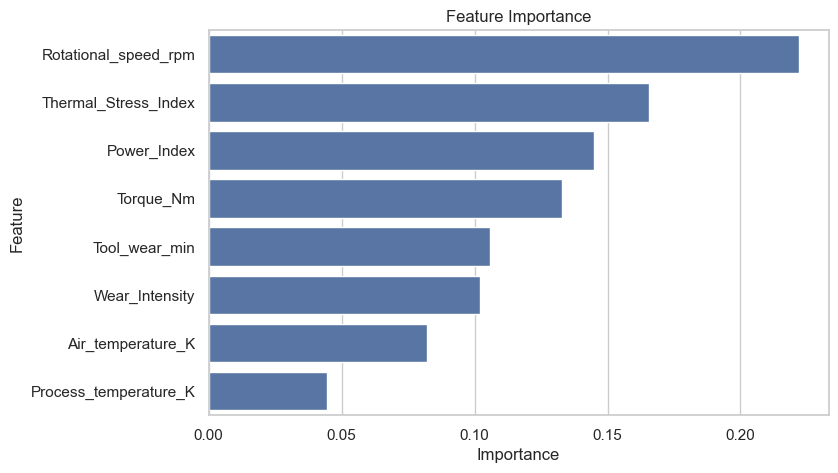

,Feature,Importance
2,Rotational_speed_rpm,0.222046
7,Thermal_Stress_Index,0.165436
5,Power_Index,0.144943
3,Torque_Nm,0.132732
4,Tool_wear_min,0.105925
6,Wear_Intensity,0.102170
0,Air_temperature_K,0.082076
1,Process_temperature_K,0.044671


In [51]:
# ----------------------------------
# Feature Importance
# ----------------------------------

importance = pd.DataFrame({

    "Feature":features,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

plt.figure(figsize=(8,5))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature"

)

plt.title("Feature Importance")

plt.show()

importance

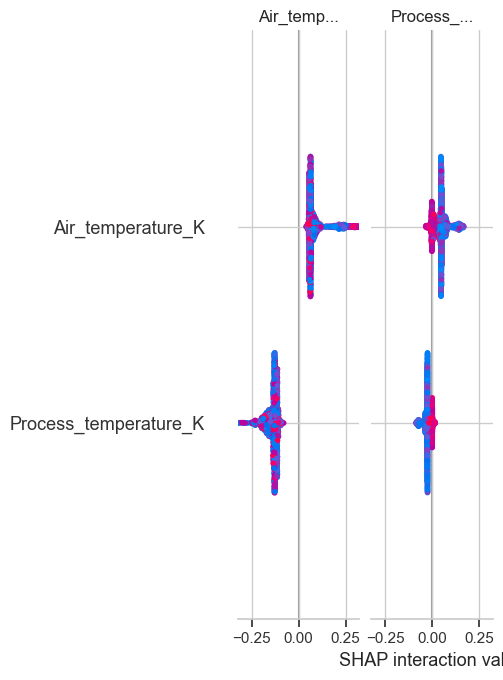

In [52]:
# ----------------------------------
# SHAP Explainability
# ----------------------------------

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(

    shap_values,

    X_test

)

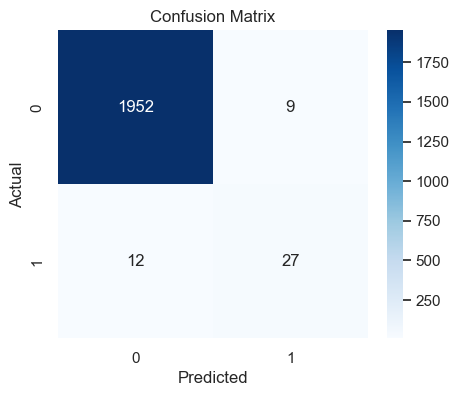

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1961
           1       0.75      0.69      0.72        39

    accuracy                           0.99      2000
   macro avg       0.87      0.84      0.86      2000
weighted avg       0.99      0.99      0.99      2000



In [53]:
# ----------------------------------
# Model Evaluation
# ----------------------------------

cm = confusion_matrix(

    y_test,

    final_prediction

)

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

print(

    classification_report(

        y_test,

        final_prediction

    )

)

In [54]:
# ----------------------------------
# Equipment Health Index (EHI)
# ----------------------------------

warning_threshold = max(

    optimal_threshold * 0.5,

    0.05

)

critical_threshold = min(

    optimal_threshold + (1-optimal_threshold)*0.5,

    0.95

)


def risk(score):

    score = score * 100

    if score < warning_threshold*100:

        return "Healthy"

    elif score < optimal_threshold*100:

        return "Warning"

    elif score < critical_threshold*100:

        return "High Risk"

    else:

        return "Critical"

In [55]:
# ----------------------------------
# Prediction Dashboard Data
# ----------------------------------

dashboard = X_test.copy()

dashboard["Failure Probability"] = final_probability

dashboard["Equipment Health Risk Index"] = final_probability * 100

dashboard["Risk Level"] = dashboard["Failure Probability"].apply(risk)

dashboard = dashboard.sort_values(

    by="Equipment Health Risk Index",

    ascending=False

)

dashboard.head(10)

,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Power_Index,Wear_Intensity,Thermal_Stress_Index,Failure Probability,Equipment Health Risk Index,Risk Level
8398,298.5,309.7,2617,12.1,102,31665.7,1234.2,3747.37,1.000000,100.000000,Critical
8245,299.0,310.3,1303,68.6,111,89385.8,7614.6,21286.58,1.000000,100.000000,Critical
9014,297.2,308.1,1340,61.3,207,82142.0,12689.1,18886.53,0.985714,98.571429,Critical
9659,298.9,309.8,1287,61.9,216,79665.3,13370.4,19176.62,0.970330,97.032967,Critical
9084,297.2,307.9,1326,75.4,172,99980.4,12968.8,23215.66,0.969230,96.923045,Critical
9974,298.6,308.2,1361,68.2,172,92820.2,11730.4,21019.24,0.967224,96.722408,Critical
8192,299.6,310.9,1229,65.2,209,80130.8,13626.8,20270.68,0.952938,95.293837,Critical
8846,297.4,308.8,1325,62.4,204,82680.0,12729.6,19269.12,0.952938,95.293837,Critical
8356,298.6,309.6,1344,59.4,200,79833.6,11880.0,18390.24,0.895596,89.559571,Critical
9654,299.1,310.0,1367,56.3,203,76962.1,11428.9,17453.00,0.895596,89.559571,Critical


In [56]:
# ----------------------------------
# Save Model and Dashboard
# ----------------------------------

version = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

joblib.dump(

    scoring_model,

    f"Predictive_Maintenance_Model_{version}.joblib"

)

dashboard.to_csv(

    f"Dashboard_Data_{version}.csv",

    index=False

)

config = {

    "Model":best_model_name,

    "Threshold":float(optimal_threshold),

    "Version":version

}

with open(

    f"Model_Config_{version}.json",

    "w"

) as file:

    json.dump(

        config,

        file,

        indent=4

    )

print("Files Saved Successfully.")

Files Saved Successfully.


In [57]:
dashboard.head()



,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Power_Index,Wear_Intensity,Thermal_Stress_Index,Failure Probability,Equipment Health Risk Index,Risk Level
8398,298.5,309.7,2617,12.1,102,31665.7,1234.2,3747.37,1.000000,100.000000,Critical
8245,299.0,310.3,1303,68.6,111,89385.8,7614.6,21286.58,1.000000,100.000000,Critical
9014,297.2,308.1,1340,61.3,207,82142.0,12689.1,18886.53,0.985714,98.571429,Critical
9659,298.9,309.8,1287,61.9,216,79665.3,13370.4,19176.62,0.970330,97.032967,Critical
9084,297.2,307.9,1326,75.4,172,99980.4,12968.8,23215.66,0.969230,96.923045,Critical


In [58]:
display(dashboard.tail())

display(dashboard["Risk Level"].value_counts())

display(dashboard.describe())

,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Power_Index,Wear_Intensity,Thermal_Stress_Index,Failure Probability,Equipment Health Risk Index,Risk Level
8930,297.4,308.4,1571,39.4,0,61897.4,0.0,12150.96,0.0,0.0,Healthy
9479,298.9,309.6,1600,33.5,175,53600.0,5862.5,10371.60,0.0,0.0,Healthy
8620,297.6,308.5,1475,42.4,24,62540.0,1017.6,13080.40,0.0,0.0,Healthy
8619,297.6,308.6,1480,39.8,19,58904.0,756.2,12282.28,0.0,0.0,Healthy
9999,299.0,308.7,1500,40.2,30,60300.0,1206.0,12409.74,0.0,0.0,Healthy


Risk Level
Healthy      1956
Critical       19
High Risk      17
Warning         8
Name: count, dtype: int64

,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Power_Index,Wear_Intensity,Thermal_Stress_Index,Failure Probability,Equipment Health Risk Index
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,298.402050,309.395100,1534.493000,40.024800,106.246000,60016.834850,4245.573100,12383.168435,0.017941,1.794136
std,0.901913,1.052492,165.329244,9.655519,63.124265,9913.869967,2800.196775,2986.184423,0.101318,10.131799
min,296.700000,307.400000,1181.000000,12.100000,0.000000,31665.700000,0.000000,3747.370000,0.000000,0.000000
25%,297.500000,308.600000,1425.750000,33.300000,51.000000,53397.900000,1947.600000,10312.177500,0.000000,0.000000
50%,298.400000,309.200000,1504.000000,40.100000,106.000000,59793.300000,3922.400000,12406.335000,0.000587,0.058737
75%,298.900000,310.100000,1609.000000,46.400000,161.000000,66754.150000,6226.400000,14368.717500,0.001986,0.198597
max,301.000000,312.100000,2636.000000,75.400000,246.000000,99980.400000,13626.800000,23215.660000,1.000000,100.000000


In [59]:
import os

print(os.getcwd())
print()
print(os.listdir())

C:\Users\Nill\DCP

['.ipynb_checkpoints', 'catboost_info', 'Dashboard.ipynb.ipynb', 'Dashboard_Data_20260714_055511.csv', 'Dashboard_Data_20260714_152250.csv', 'Data_understanding.ipynb', 'DCP_data', 'IMS_Vibration_Analysis.ipynb.ipynb', 'IMS_Vibration_Features.csv', 'Model_Config_20260714_152250.json', 'Predictive_Maintenance_Model_20260714_055511.joblib', 'Predictive_Maintenance_Model_20260714_152250.joblib', 'Untitled.ipynb']
